In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out.csv')

In [3]:
data=data.sample(frac=1)
data.drop(['Unnamed: 0','Shape','active_channel_count','root','Gas_Type','avg'],axis=1,inplace=True)
#data= data.set_index('Event')
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
41,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,5500,cs,1.52,11
228,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,4000,kaynaksız,1.52,0
12,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,3000,cs,1.52,1
149,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,4000,kaynaksız,1.52,2
227,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,8000,cs,1.52,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,7000,cs,1.52,7
250,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,4000,cs,1.52,85
96,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,7000,kaynaksız,1.52,49
201,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,6500,cs,1.52,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 41 to 2
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               273 non-null    float64
 1   Ar                273 non-null    float64
 2   N2                273 non-null    float64
 3   CO2               273 non-null    float64
 4   C                 273 non-null    float64
 5   O                 273 non-null    float64
 6   H                 273 non-null    float64
 7   Detector_Size     273 non-null    float64
 8   Detector_Area     273 non-null    float64
 9   Cover_Size        273 non-null    float64
 10  Cover_Area        273 non-null    float64
 11  Cover_Area_Ratio  273 non-null    float64
 12  Voltage           273 non-null    int64  
 13  Source            273 non-null    object 
 14  Time_Window       273 non-null    float64
 15  Peak_Count        273 non-null    int64  
dtypes: float64(13), int64(2), object(1)
memory usage: 

In [5]:
data.isnull()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
41,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
228,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
149,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
227,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
250,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
201,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

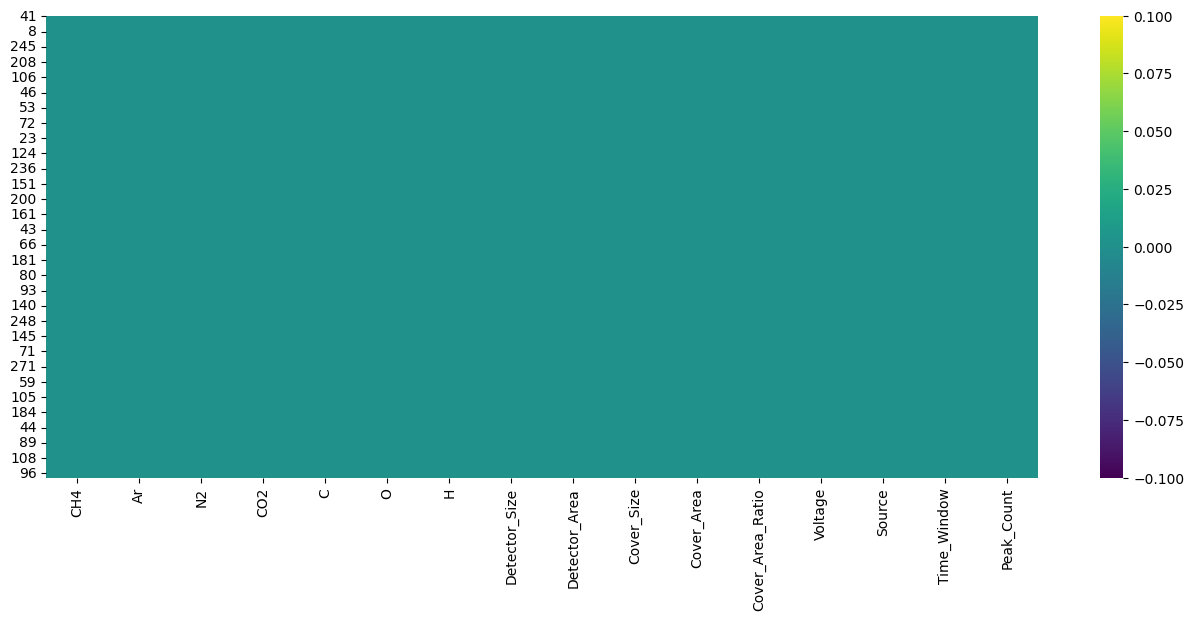

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [10]:
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
41,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,5500,cs,1.52,11
228,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,4000,kaynaksız,1.52,0
12,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,3000,cs,1.52,1
149,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,4000,kaynaksız,1.52,2
227,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,8000,cs,1.52,30


In [11]:
type2=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type2

,kaynaksız
41,0.0
228,1.0
12,0.0
149,1.0
227,0.0
...,...
232,0.0
250,0.0
96,1.0
201,0.0


In [12]:
type=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type

,kaynaksız
41,0.0
228,1.0
12,0.0
149,1.0
227,0.0
...,...
232,0.0
250,0.0
96,1.0
201,0.0


In [13]:
data=pd.concat([data,type2],axis=1)
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,kaynaksız
41,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,5500,cs,1.52,11,0.0
228,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,4000,kaynaksız,1.52,0,1.0
12,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,3000,cs,1.52,1,0.0
149,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,4000,kaynaksız,1.52,2,1.0
227,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,8000,cs,1.52,30,0.0


In [14]:
data.drop(['Source'],axis=1,inplace=True)
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,kaynaksız
41,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,5500,1.52,11,0.0
228,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,4000,1.52,0,1.0
12,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,3000,1.52,1,0.0
149,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,4000,1.52,2,1.0
227,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,8000,1.52,30,0.0


In [15]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 41 to 2
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               273 non-null    float64
 1   Ar                273 non-null    float64
 2   N2                273 non-null    float64
 3   CO2               273 non-null    float64
 4   C                 273 non-null    float64
 5   O                 273 non-null    float64
 6   H                 273 non-null    float64
 7   Detector_Size     273 non-null    float64
 8   Detector_Area     273 non-null    float64
 9   Cover_Size        273 non-null    float64
 10  Cover_Area        273 non-null    float64
 11  Cover_Area_Ratio  273 non-null    float64
 12  Voltage           273 non-null    int64  
 13  Time_Window       273 non-null    float64
 14  Peak_Count        273 non-null    int64  
 15  kaynaksız         273 non-null    float64
dtypes: float64(14), int64(2)
memory usage: 36.3 KB


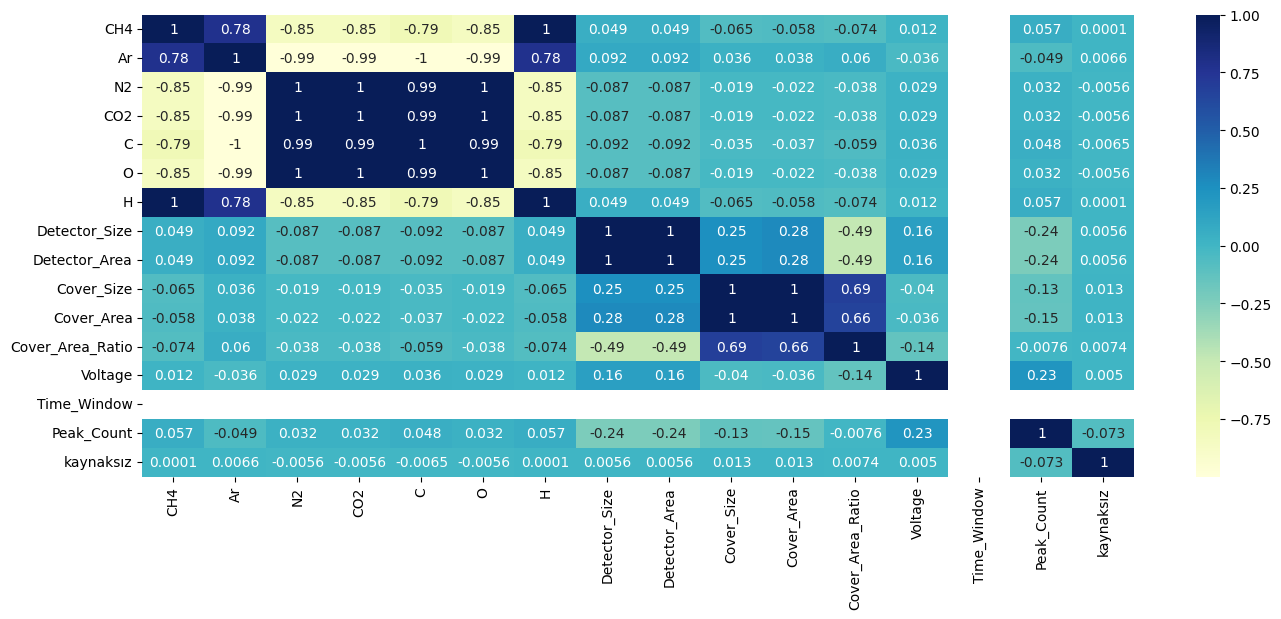

In [16]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [17]:
corrM[abs(corrM['Peak_Count'])>0.05][['Peak_Count']]

,Peak_Count
CH4,0.056663
H,0.056663
Detector_Size,-0.240341
Detector_Area,-0.240341
Cover_Size,-0.133875
Cover_Area,-0.145378
Voltage,0.225220
Peak_Count,1.000000
kaynaksız,-0.073108


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x=data.drop(['Peak_Count'],axis=1)
x=data[['H','Detector_Area','Cover_Area','kaynaksız']]

x.head()

,H,Detector_Area,Cover_Area,kaynaksız
41,0.08,100.0,16.0,0.0
228,0.00,100.0,64.0,1.0
12,0.08,100.0,36.0,0.0
149,0.16,100.0,64.0,1.0
227,0.00,100.0,64.0,0.0


In [20]:
y=data['Peak_Count']
y

41      11
228      0
12       1
149      2
227     30
      ... 
232      7
250     85
96      49
201      0
2      114
Name: Peak_Count, Length: 273, dtype: int64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model=LinearRegression()

In [24]:
model.fit(X_train,y_train)

LinearRegression()

In [25]:
pred=model.predict(X_test)
pred

array([53.32415519,  7.93019643, 73.1002171 , 24.62354127, 39.64745108,
       73.1002171 , 73.1002171 , 19.25767911, 73.1002171 , 53.32415519,
       63.95515929, 29.01644698, 51.0913702 , 85.96400618, 12.32310214,
       51.0913702 , -2.70080767, 19.25767911, 24.57318115, 46.58202805,
       75.33300208, 46.58202805, 41.266526  ,  2.61469438, 53.32415519,
       12.32310214, 13.94217706,  7.93019643, 51.0913702 , 19.30803922,
       29.01644698, 53.32415519, 34.33194903, 75.33300208, 46.58202805,
       53.32415519, 51.0913702 , 17.63860418, 53.32415519, 46.58202805,
       46.58202805, 19.25767911,  2.61469438, 75.33300208, 29.93904332,
       63.95515929, -2.70080767,  7.00760009, 13.94217706,  2.61469438,
       73.1002171 , 12.32310214, 85.96400618, -2.70080767, 53.32415519])

In [26]:
y_test

272    112
161      4
87       1
77      17
123     72
94       0
82      16
46       6
86      21
244      0
167    156
201      0
79      40
180      0
15       2
84       3
239     12
29      17
135      5
132      1
263     43
136     53
39      31
63      19
264     13
8        0
215      0
164     26
88       0
240      0
197     12
262    131
27       0
265     41
127      1
267     95
91      26
107     10
252     78
131     19
142     22
43      13
70       0
257     61
155      0
186    522
236      0
209      1
220      1
69      26
101      1
18       3
184     10
243      0
247     54
Name: Peak_Count, dtype: int64

In [27]:
X_test

,H,Detector_Area,Cover_Area,kaynaksız
272,0.00,45.97,22.85,1.0
161,0.16,100.00,64.00,1.0
87,0.08,45.97,44.62,0.0
77,0.08,100.00,64.00,0.0
123,0.16,100.00,36.00,0.0
94,0.08,45.97,44.62,0.0
82,0.08,45.97,44.62,0.0
46,0.08,100.00,16.00,1.0
86,0.08,45.97,44.62,0.0
244,0.00,45.97,22.85,1.0


In [28]:
model.score(X_test, y_test)

0.05946874302910987

In [29]:
pred

array([53.32415519,  7.93019643, 73.1002171 , 24.62354127, 39.64745108,
       73.1002171 , 73.1002171 , 19.25767911, 73.1002171 , 53.32415519,
       63.95515929, 29.01644698, 51.0913702 , 85.96400618, 12.32310214,
       51.0913702 , -2.70080767, 19.25767911, 24.57318115, 46.58202805,
       75.33300208, 46.58202805, 41.266526  ,  2.61469438, 53.32415519,
       12.32310214, 13.94217706,  7.93019643, 51.0913702 , 19.30803922,
       29.01644698, 53.32415519, 34.33194903, 75.33300208, 46.58202805,
       53.32415519, 51.0913702 , 17.63860418, 53.32415519, 46.58202805,
       46.58202805, 19.25767911,  2.61469438, 75.33300208, 29.93904332,
       63.95515929, -2.70080767,  7.00760009, 13.94217706,  2.61469438,
       73.1002171 , 12.32310214, 85.96400618, -2.70080767, 53.32415519])

In [30]:
y_test

272    112
161      4
87       1
77      17
123     72
94       0
82      16
46       6
86      21
244      0
167    156
201      0
79      40
180      0
15       2
84       3
239     12
29      17
135      5
132      1
263     43
136     53
39      31
63      19
264     13
8        0
215      0
164     26
88       0
240      0
197     12
262    131
27       0
265     41
127      1
267     95
91      26
107     10
252     78
131     19
142     22
43      13
70       0
257     61
155      0
186    522
236      0
209      1
220      1
69      26
101      1
18       3
184     10
243      0
247     54
Name: Peak_Count, dtype: int64

In [31]:
indexes = X_test.index.values
len(indexes)

55

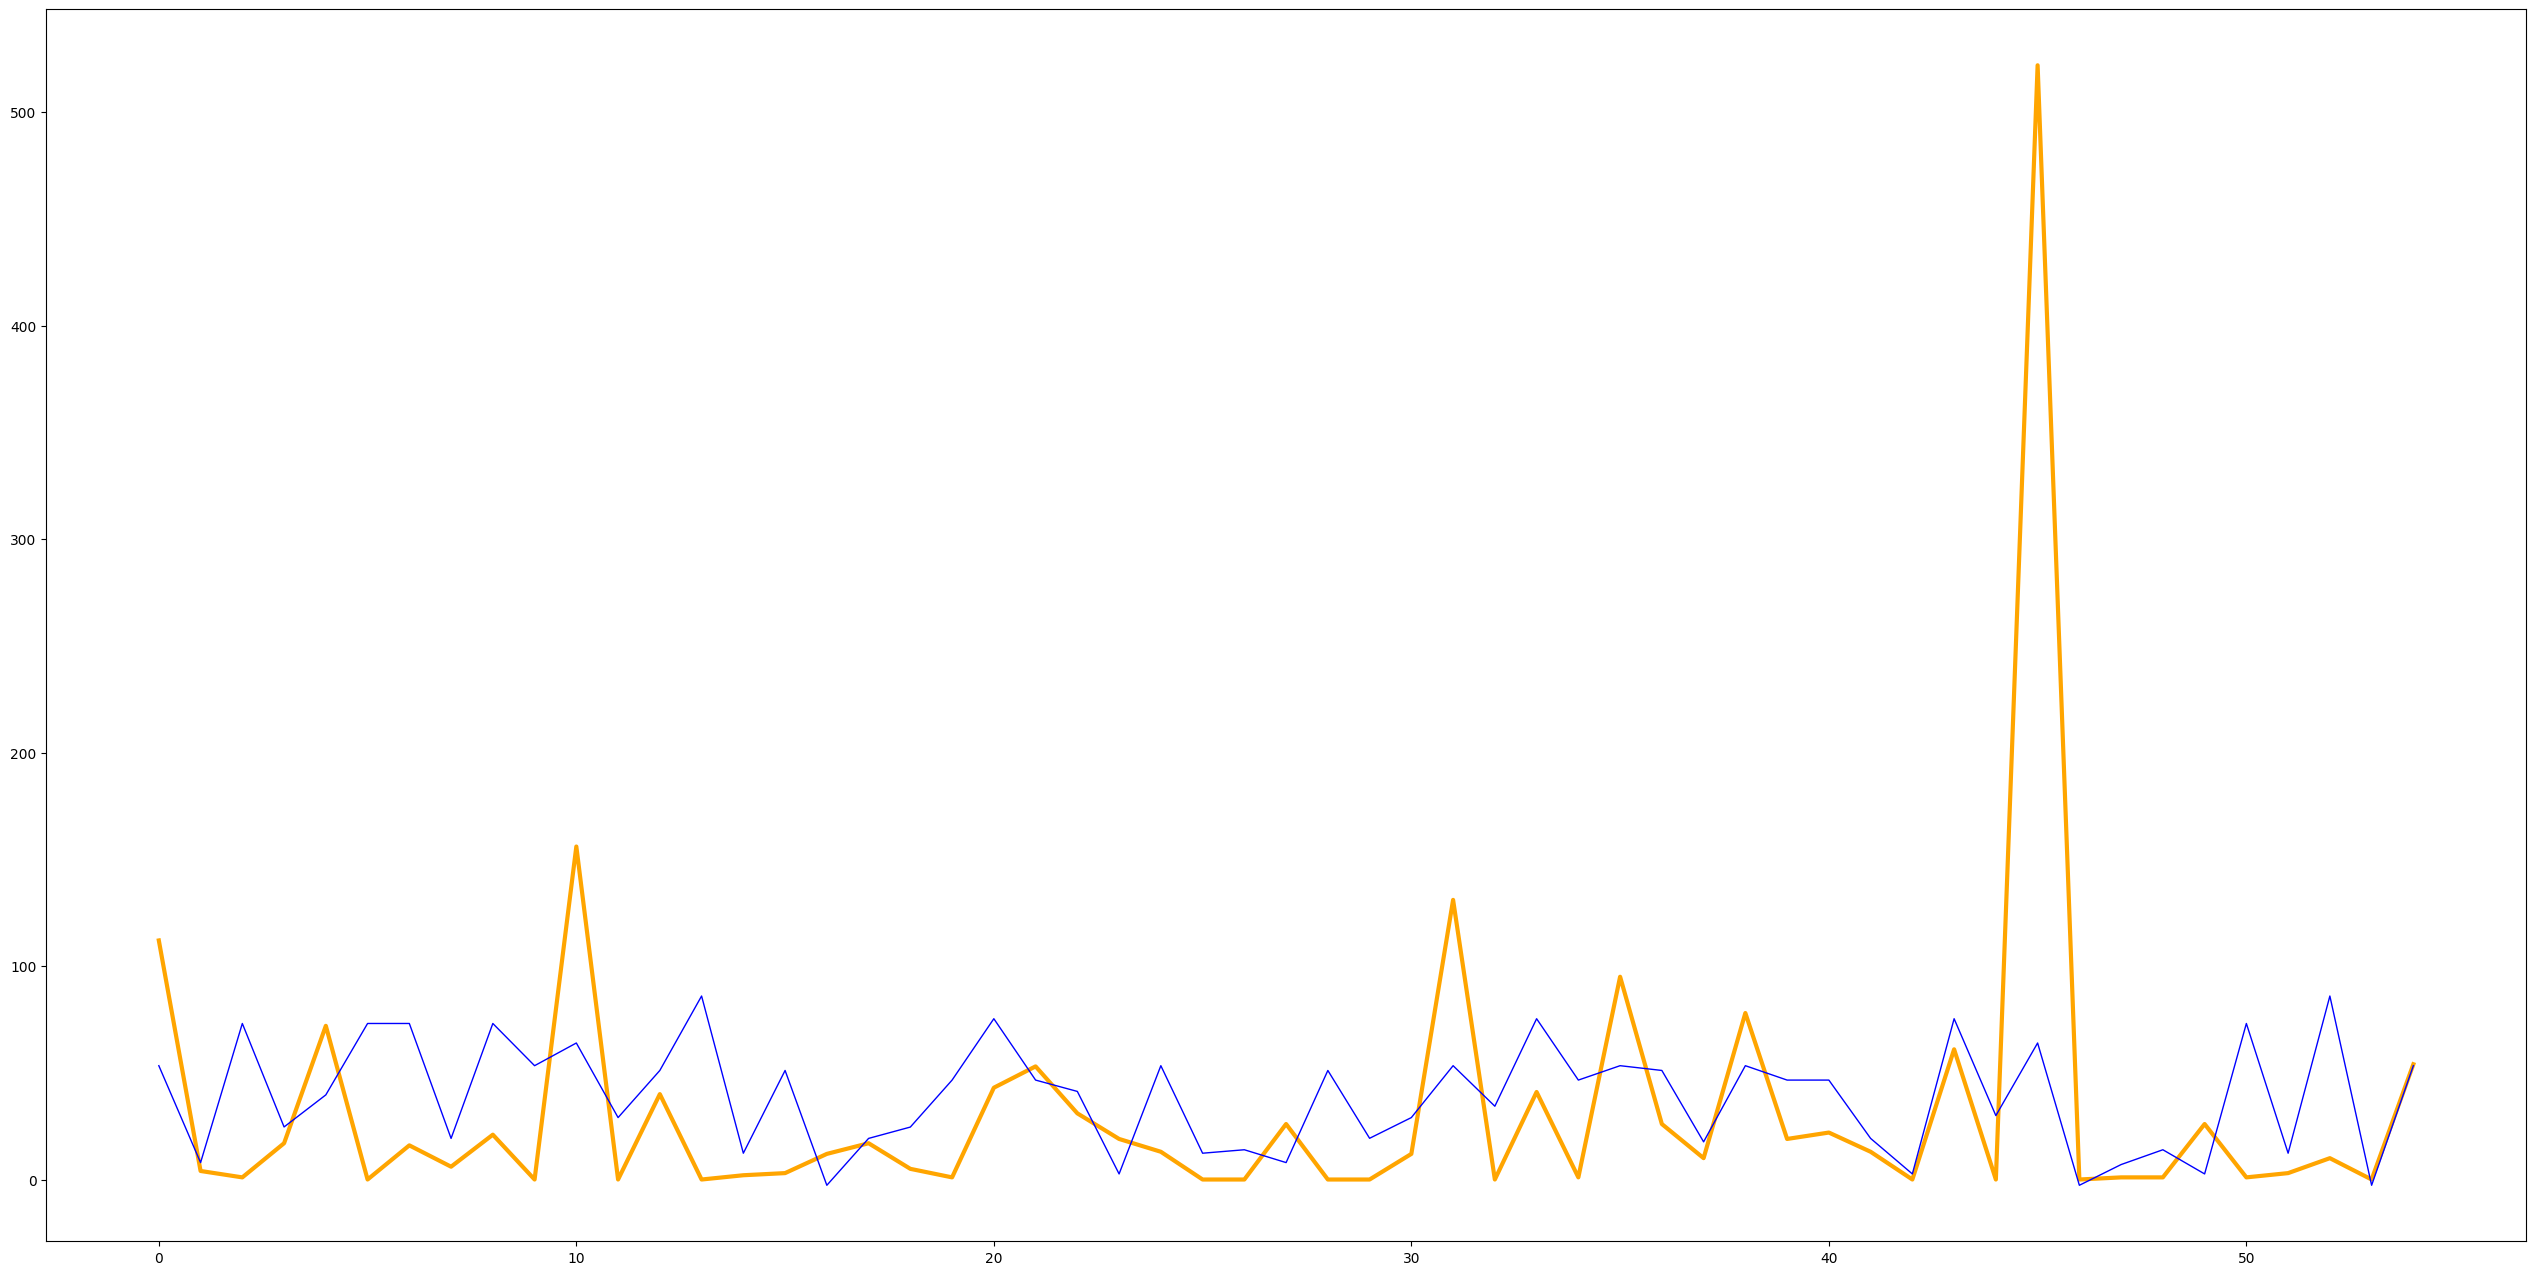

In [32]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes)),y_test, color="orange", linewidth=3)
plt.plot(range(0,len(indexes)),pred, color="blue", linewidth=1)
plt.show()